In [1]:
from denovo_utils.io.read import read_features
from glob import glob
import os
from denovo_utils.io.read import load_pickle
from denovo_utils.data import Spectrum
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

%matplotlib inline

2026-09-09 09:13:30.342850: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Modification already exists in ModificationsDB. Skipping.


In [2]:
from figsave import autosave
autosave("figures", formats=("svg", "pdf"))

PosixPath('figures')

In [3]:
denovo_names = denovo_engines = [
    'AdaNovo',
    'Casanovo4.2.0',
    'ContraNovo',
    'InstaNovo',
    'NovoB',
    'PepNet',
    'pi-HelixNovo',
    'pi-PrimeNovo',
]

import pickle
with open('runs_PXD028735_QExactive_modcleanup.pkl', 'rb') as f:
    runs = pickle.load(f)

In [4]:
ordering = ['match', 'No match - In FASTA', 'No match - Not in FASTA']

def get_best_rank_gold_standard(psms):
    for psm in psms:
        if psm.rank ==1:
            return psm

def get_best_predictions(spectrum: Spectrum, engines: list):
    entry = {
        engine: False for engine in engines
    }
    entry['psm_gt'] = get_best_rank_gold_standard(spectrum.psm_gold_standard)
    entry['match_type'] = None
    entry['score_diff'] = np.nan
    
    for engine in engines:
        psms = spectrum.get_psms_by_engine(engine)
        if psms == []:
            continue
        
        for psm in psms:
    
            psm_match_type = psm.metadata['match_type']
            psm_score_diff = psm.evaluations[1]['score_ms2rescore'].score_diff

            if psm_match_type == 'match':
                entry['match_type'] = psm_match_type
                entry['score_diff'] = psm_score_diff
                entry['psm_denovo'] = psm
                entry[engine] = True

            else:
                if entry['match_type'] == None:
                    entry['match_type'] = psm_match_type
                    entry['score_diff'] = psm_score_diff
                    entry['psm_denovo'] = psm

                elif ordering.index(entry['match_type']) > ordering.index(psm_match_type):
                    entry['match_type'] = psm_match_type
                    entry['psm_denovo'] = psm
                    entry['score_diff'] = psm_score_diff
                elif entry['match_type'] == psm_match_type:
                    if psm_score_diff < entry['score_diff']:
                        entry['psm_denovo'] = psm
                        entry['score_diff'] = psm_score_diff
    return entry

df = []
for run_name, run in runs.items():
    for specid, spectrum in run.spectra.items():
        entry = get_best_predictions(spectrum, denovo_engines)
        entry['run'] = run_name
        entry['spectrum_id'] = specid
        df.append(entry)
df = pd.DataFrame(df)

In [5]:
df[denovo_engines].sum() / len(df)

AdaNovo          0.350640
Casanovo4.2.0    0.429434
ContraNovo       0.251608
InstaNovo        0.445949
NovoB            0.428403
PepNet           0.238715
pi-HelixNovo     0.367802
pi-PrimeNovo     0.504434
dtype: float64

In [6]:
df['has_correct'] = df[denovo_engines].any(axis=1)
df['has_correct'].value_counts(normalize=True)

has_correct
True     0.642127
False    0.357873
Name: proportion, dtype: float64

In [7]:
df.match_type.value_counts(normalize=True)

match_type
match                      0.642364
No match - Not in FASTA    0.250166
No match - In FASTA        0.107470
Name: proportion, dtype: float64

Create the features parquet files by combining sage and msgf

Construct the gold standard by also including the features when merging.
Afterwards, save both separately.

In [8]:
root = '/public/compomics3/Sam/PXD028735/QExactive/reviewer/rescoring/chimeric'
features = []
for p in glob(os.path.join(root, '*')):
    if p.endswith('.txt'):
        continue
    path = os.path.join(p, 'features', 'sage_msgf.parquet')
    features.append(read_features(path=path))
features = pd.concat(features, ignore_index=True)

In [9]:
def get_features_from_entries(features, entries):

    selections = []
    for run_name in runs.keys():
        selection = features[
            (features['run']==run_name) &
            (features['spectrum_id'].isin(entries[entries.run==run_name]['spectrum_id'].tolist()))
        ]
        selections.append(selection)

    features_selection = pd.DataFrame(pd.concat(selections)['rescoring_features'].tolist())
    return features_selection

def get_features(features, entries):
    features_match = get_features_from_entries(features=features, entries=entries['match'])
    features_in_fasta = get_features_from_entries(features=features, entries=entries['in_fasta'])
    features_not_in_fasta = get_features_from_entries(features=features, entries=entries['not_in_fasta'])

    features_match['match_type'] = 'match'
    features_in_fasta['match_type'] = 'No match - In FASTA'
    features_not_in_fasta['match_type'] = 'No match - Not in FASTA'

    features_selection = pd.concat(
        [features_match, features_in_fasta, features_not_in_fasta],
        ignore_index=True
    )
    return features_selection

In [10]:
features_rank_1 = features[features['rank']==1]

In [11]:
match_entries = df[df.match_type=='match'][['run', 'spectrum_id']]
in_fasta_entries = df[df.match_type=='No match - In FASTA'][['run', 'spectrum_id']]
not_in_fasta_entries = df[df.match_type=='No match - Not in FASTA'][['run', 'spectrum_id']]

entries = {
    'match': match_entries,
    'in_fasta': in_fasta_entries,
    'not_in_fasta': not_in_fasta_entries
}

features_all = get_features(features=features_rank_1, entries=entries)

In [12]:
features_all['match_type'].value_counts(normalize=True)

match_type
match                      0.642364
No match - Not in FASTA    0.250166
No match - In FASTA        0.107470
Name: proportion, dtype: float64

In [13]:
def annotate_stacked_histplot(ax):
    # Get the bars' heights
    patches = ax.patches

    # Grouping bars by bins
    heights_by_bin = {}

    # Loop through each patch and store heights by bin
    for patch in patches:
        # The bin location is the x-coordinate of the patch
        bin_location = patch.get_x()
        
        # Store height based on bin location
        if bin_location not in heights_by_bin:
            heights_by_bin[bin_location] = []
        heights_by_bin[bin_location].append(patch.get_height())

    # Annotate percentages
    for bin_location, heights in heights_by_bin.items():
        total_height = sum(heights)
        
        # Calculate percentage and annotate each stack if greater than 5%
        cumulative_height = 0
        for height in heights:
            percentage = (height / total_height) * 100
            
            if percentage > 5:
                # Get the center x-coordinate of the patch
                x = bin_location + 0.25  # Adjust based on binwidth
                
                # Annotate the center of each bar in the stack
                y = cumulative_height + height / 2  # Midpoint of the bar
                
                # Add annotation to the plot
                ax.text(x, y, f'{percentage:.0f}%', ha='center', va='center', color='black', fontsize=8)
            
            # Update cumulative height for stacking annotations
            cumulative_height += height

hue_order = [
    'match',
    'No match - In FASTA',
    'No match - Not in FASTA'
]

sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True

status_lut = {
    "match":                   "#009E73",  # green
    "No match - In FASTA":     "#E69F00",  # orange
    "No match - Not in FASTA": "#D55E00",  # red
}

In [14]:
features_all['missing_frag_sites'] = features_all['missing_frag_sites'].astype(int)
features_all['peptide_len'] = features_all['peptide_len'].astype(int)

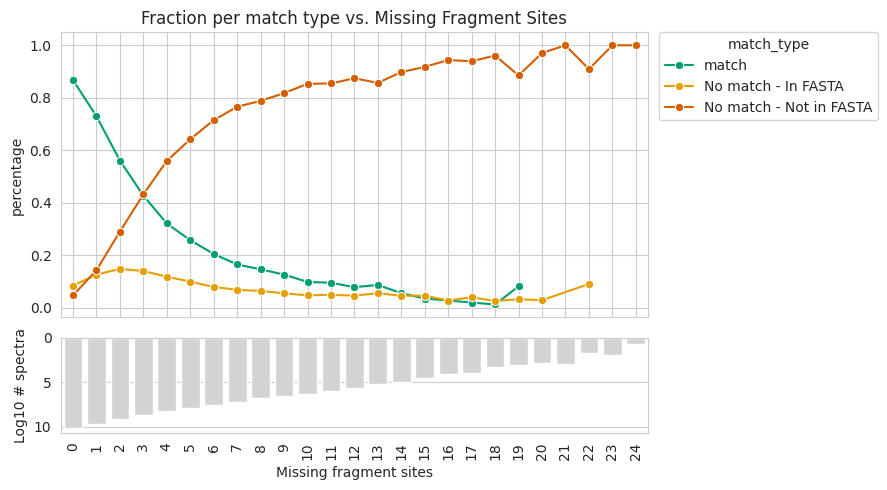

In [15]:
missing_by_counts = features_all.groupby('missing_frag_sites').match_type.value_counts(normalize=True)
missing_by_counts.name = 'percentage'
missing_by_counts = missing_by_counts.reset_index()

missing_by_counts_2 = features_all.groupby('missing_frag_sites').match_type.value_counts(normalize=False)
missing_by_counts_2.name = 'count'
missing_by_counts_2 = missing_by_counts_2.reset_index()

missing_by_counts = pd.concat([
    missing_by_counts,
    missing_by_counts_2['count']
], axis=1)

# Create subplots: one above (line + dots), one below (bar plot)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(9, 5), 
                               gridspec_kw={'height_ratios': [3, 1]})

# --- Top plot: line + points
sns.lineplot(
    data=missing_by_counts,
    x='missing_frag_sites',
    y='percentage',
    hue='match_type',
    palette=status_lut,
    ax=ax1,
    marker='o',  # adds dots at each data point,
    legend=True
)
ax1.legend(
    title="match_type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

# --- Bottom plot: reversed bar plot
sns.barplot(
    data=missing_by_counts.groupby('missing_frag_sites')['count'].mean().apply(lambda x: np.log(x)).reset_index(),
    x='missing_frag_sites',
    y='count',
    color='lightgray',
    ax=ax2,
    legend=False
)

ax1.set_title("Fraction per match type vs. Missing Fragment Sites")
ax2.invert_yaxis()  # reverse the y-axis
ax2.set_ylabel("Log10 # spectra")
ax2.set_xlabel("Missing fragment sites")

plt.setp(ax2.get_xticklabels(), rotation=90)

plt.tight_layout()
plt.show("F8A_MFS")

In [19]:
with pd.ExcelWriter('source_data/Source_Data_Figure5.xlsx', engine='openpyxl') as xl:
    missing_by_counts.to_excel(xl, sheet_name='A', index=False)

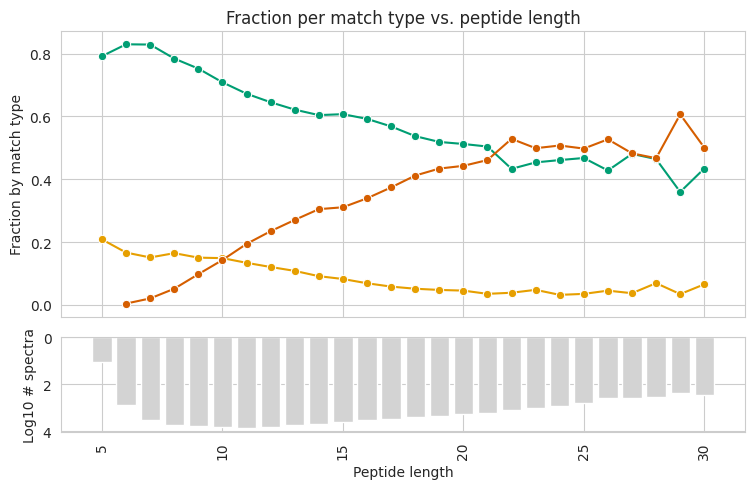

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Prepare data
missing_by_counts = features_all.groupby('peptide_len').match_type.value_counts(normalize=True)
missing_by_counts.name = 'percentage'
missing_by_counts = missing_by_counts.reset_index()
missing_by_counts['peptide_len'] = missing_by_counts['peptide_len'].astype(int)

missing_by_counts_2 = features_all.groupby('peptide_len').match_type.value_counts(normalize=False)
missing_by_counts_2.name = 'count'
missing_by_counts_2 = missing_by_counts_2.reset_index()

missing_by_counts = pd.concat([
    missing_by_counts,
    missing_by_counts_2['count']
], axis=1)

# --- Aggregate for bar plot
barplot_ = missing_by_counts.groupby('peptide_len')['count'].mean().apply(lambda x: np.log10(x)).reset_index()
barplot_['peptide_len'] = barplot_['peptide_len'].astype(int)

# --- Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(9, 5), 
                               gridspec_kw={'height_ratios': [3, 1]})

# --- Top: line + points
sns.lineplot(
    data=missing_by_counts,
    x='peptide_len',
    y='percentage',
    hue='match_type',
    palette=status_lut,
    ax=ax1,
    marker='o',
    legend=False
)
ax1.set_ylabel("Fraction by match type")
ax1.set_title("Fraction per match type vs. peptide length")


# --- Bottom: bars using matplotlib to keep numeric alignment
ax2.bar(
    barplot_['peptide_len'],
    barplot_['count'],
    color='lightgray',
    width=0.8  # adjust width for visual spacing
)
ax2.invert_yaxis()  # reverse y-axis
ax2.set_ylabel("Log10 # spectra")
ax2.set_xlabel("Peptide length")
plt.setp(ax2.get_xticklabels(), rotation=90)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave space for legend
plt.show("F8B_peplen")

In [22]:
with pd.ExcelWriter('source_data/Source_Data_Figure5.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as xl:
    missing_by_counts.to_excel(xl, sheet_name='B', index=False)

In [23]:
expl_intensity = features_all[['explained_by_pct', 'match_type']]

expl_intensity['binned'] = pd.cut(
    expl_intensity['explained_by_pct'].tolist(), bins=np.arange(0,1,.025)
)
expl_intensity['binned'] = expl_intensity['binned'].astype(str)

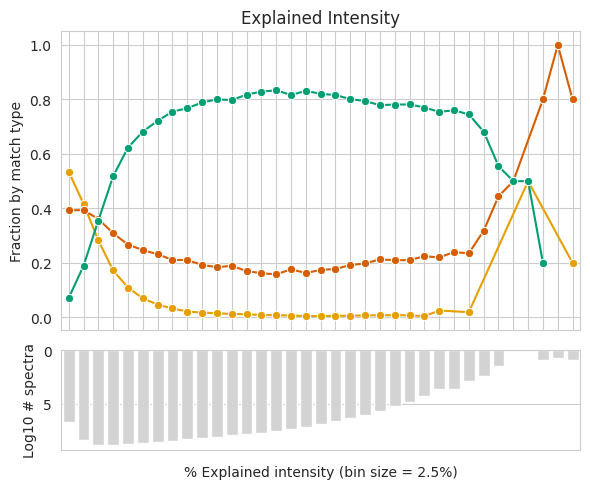

In [24]:
# features_all['peptide_len'] = pd.to_numeric(features_all['peptide_len'])

missing_by_counts = expl_intensity.groupby('binned').match_type.value_counts(normalize=True)
missing_by_counts.name = 'percentage'
missing_by_counts = missing_by_counts.reset_index()

missing_by_counts_2 = expl_intensity.groupby('binned').match_type.value_counts(normalize=False)
missing_by_counts_2.name = 'count'
missing_by_counts_2 = missing_by_counts_2.reset_index()

missing_by_counts = pd.concat([
    missing_by_counts,
    missing_by_counts_2['count']
], axis=1)

# Create subplots: one above (line + dots), one below (bar plot)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 5), 
                               gridspec_kw={'height_ratios': [3, 1]})

# --- Top plot: line + points
sns.lineplot(
    data=missing_by_counts,
    x='binned',
    y='percentage',
    hue='match_type',
    palette=status_lut,
    ax=ax1,
    marker='o',  # adds dots at each data point,
    legend=False
)
ax1.set_ylabel("Fraction by match type")
ax1.set_title("Explained Intensity")

# --- Bottom plot: reversed bar plot
sns.barplot(
    data=missing_by_counts.groupby('binned')['count'].mean().apply(lambda x: np.log(x)).reset_index(),
    x='binned',
    y='count',
    color='lightgray',
    ax=ax2,
    legend=False
)

ax1.set_xlabel('')
_ = ax1.set_xticklabels('')
_ = ax2.set_xticklabels('')
ax2.invert_yaxis()  # reverse the y-axis
ax2.set_ylabel("Log10 # spectra")
ax2.set_xlabel("% Explained intensity (bin size = 2.5%)")
plt.tight_layout()
plt.show("F8C_ExplInt")

In [25]:
with pd.ExcelWriter('source_data/Source_Data_Figure5.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as xl:
    missing_by_counts.to_excel(xl, sheet_name='C', index=False)

In [26]:
missing_by_counts[missing_by_counts['percentage']>.8].sort_values('percentage')

,binned,match_type,percentage,count
30,"(0.25, 0.275]",match,0.800223,7903
57,"(0.475, 0.5]",match,0.801260,1399
54,"(0.45, 0.475]",match,0.816132,1882
45,"(0.375, 0.4]",match,0.816275,3892
36,"(0.3, 0.325]",match,0.817630,6057
51,"(0.425, 0.45]",match,0.820423,2563
39,"(0.325, 0.35]",match,0.828538,5702
48,"(0.4, 0.425]",match,0.831423,3265
42,"(0.35, 0.375]",match,0.833304,4744
93,"(0.85, 0.875]",No match - Not in FASTA,1.000000,2


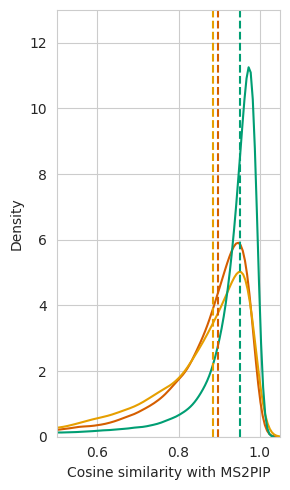

In [32]:
import numpy as np
import scipy.stats as stats
import itertools
from statsmodels.stats.multitest import multipletests

# -----------------------------
# Compute group means
# -----------------------------
medians = features_all.groupby('match_type')['cos'].median()

# -----------------------------
# Pairwise Mann–Whitney tests
# -----------------------------
pairs = list(itertools.combinations(hue_order, 2))
raw_pvals = []
pvals = {}

for g1, g2 in pairs:
    data1 = features_all.loc[
        features_all['match_type'] == g1, 'cos'
    ].values
    
    data2 = features_all.loc[
        features_all['match_type'] == g2, 'cos'
    ].values

    stat, p = stats.mannwhitneyu(
        data1,
        data2,
        alternative='two-sided'
    )

    raw_pvals.append(p)
    pvals[(g1, g2)] = p

# -----------------------------
# BH correction
# -----------------------------
_, corrected_pvals, _, _ = multipletests(
    raw_pvals,
    method='fdr_bh'
)

for key, p_corr in zip(pvals.keys(), corrected_pvals):
    pvals[key] = p_corr

# -----------------------------
# Plot KDE
# -----------------------------
plt.figure(figsize=(3,5))

ax = sns.kdeplot(
    data=features_all,
    x='cos',
    hue='match_type',
    common_norm=False,
    palette=status_lut,
    hue_order=hue_order,
    legend=False
)

# Plot means
for group in hue_order:
    ax.axvline(
        medians[group],
        color=status_lut[group],
        linestyle='--',
        linewidth=1.5
    )

plt.xlim((0.5,1.05))
plt.xlabel('Cosine similarity with MS2PIP')

# -----------------------------
# Significance annotation
# -----------------------------
def significance_label(p):
    if p < 1e-4:
        return "****"
    elif p < 1e-3:
        return "***"
    elif p < 1e-2:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

y_max = ax.get_ylim()[1]
height = y_max * 0.92
step = y_max * 0.05

# for i, (g1, g2) in enumerate(pairs):
#     x1 = medians[g1]
#     x2 = medians[g2]
#     y = height + i * step

#     ax.plot(
#         [x1, x1, x2, x2],
#         [y, y + step*0.4, y + step*0.4, y],
#         lw=1,
#         c='black'
#     )

    # ax.text(
    #     (x1 + x2) / 2,
    #     y + step*0.4,
    #     significance_label(pvals[(g1, g2)]),
    #     ha='center',
    #     va='bottom'
    # )

plt.ylim(0, height + len(pairs)*step*1.2)
plt.tight_layout()
plt.show("F8D_cosine")

In [30]:
"""Source-data tables for a seaborn kdeplot with per-group median lines."""
import pandas as pd


def kde_source_data(ax, df, value, group, group_order, figure=None, xlim=None):
    """Return (summary, density) for a kdeplot with median lines.

    `density` is harvested from the Line2D artists seaborn actually drew, so it
    matches the figure exactly with no bandwidth assumptions. NOTE seaborn draws
    hue levels in reverse order of group_order, hence ax.lines[::-1].

    Call this BEFORE adding median axvlines: those are Line2D artists too and
    would break the line-to-group mapping.
    """
    d = df[[group, value]].dropna()

    # --- curves, taken straight off the drawn artists ---
    lines = list(ax.lines)[::-1]
    if len(lines) != len(group_order):
        raise ValueError(f"{len(lines)} lines drawn but {len(group_order)} groups given; "
                         "median axvlines must be added AFTER calling this")
    dens = []
    for g, line in zip(group_order, lines):
        xy = line.get_xydata()
        part = pd.DataFrame({group: g, value: xy[:, 0], "density": xy[:, 1]})
        if xlim:                                   # keep only what the panel shows
            part = part[part[value].between(*xlim)]
        dens.append(part)
    density = pd.concat(dens, ignore_index=True)

    # --- per-group summary, including the plotted median line ---
    q = d.groupby(group)[value]
    summary = (q.agg(n="size", mean="mean", sd="std", min="min",
                     median="median", max="max")
                .reindex(group_order).rename_axis(group).reset_index())
    summary["q1"] = q.quantile(.25).reindex(group_order).values
    summary["q3"] = q.quantile(.75).reindex(group_order).values
    summary = summary[[group, "n", "min", "q1", "median", "q3", "max", "mean", "sd"]]

    if figure:
        for t in (summary, density):
            t.insert(0, "figure", figure)
    return summary, density

Text(0.5, 0, 'Cosine similarity with MS2PIP')

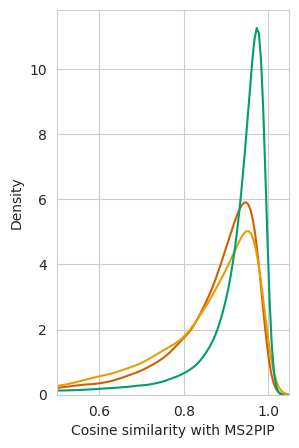

In [53]:
plt.figure(figsize=(3,5))
ax=sns.kdeplot(
    features_all,
    x='cos',
    hue='match_type',
    common_norm=False,
    palette=status_lut,
    hue_order=hue_order,
    legend=False
)
plt.xlim((0.5,1.05))
plt.xlabel('Cosine similarity with MS2PIP')

In [55]:
summary, density = kde_source_data(
    ax, features_all, value='cos', group='match_type',
    group_order=hue_order, figure="Figure 8D")

with pd.ExcelWriter("source_data/Source_Data_Figure5.xlsx", engine="openpyxl", mode='a', if_sheet_exists='replace') as xl:
    summary.round(4).to_excel(xl, sheet_name="D_summary", index=False)
    density.round(6).to_excel(xl, sheet_name="D_density", index=False)

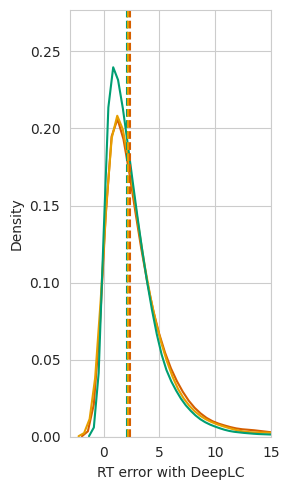

In [38]:
import numpy as np
import scipy.stats as stats
import itertools
from statsmodels.stats.multitest import multipletests

# -----------------------------
# Compute medians
# -----------------------------
medians = features_all.groupby('match_type')['rt_diff'].median()

# -----------------------------
# Pairwise Mann–Whitney tests
# -----------------------------
pairs = list(itertools.combinations(hue_order, 2))
raw_pvals = []
pvals = {}

for g1, g2 in pairs:
    data1 = features_all.loc[
        features_all['match_type'] == g1, 'rt_diff'
    ].values
    
    data2 = features_all.loc[
        features_all['match_type'] == g2, 'rt_diff'
    ].values

    stat, p = stats.mannwhitneyu(
        data1,
        data2,
        alternative='two-sided'
    )

    raw_pvals.append(p)
    pvals[(g1, g2)] = p

# -----------------------------
# BH correction
# -----------------------------
_, corrected_pvals, _, _ = multipletests(
    raw_pvals,
    method='fdr_bh'
)

for key, p_corr in zip(pvals.keys(), corrected_pvals):
    pvals[key] = p_corr

# -----------------------------
# Plot KDE
# -----------------------------
plt.figure(figsize=(3,5))

ax = sns.kdeplot(
    data=features_all,
    x='rt_diff',
    hue='match_type',
    palette=status_lut,
    common_norm=False,
    hue_order=hue_order,
    legend=False
)

# Plot medians
for group in hue_order:
    ax.axvline(
        medians[group],
        color=status_lut[group],
        linestyle='--',
        linewidth=1.5
    )

plt.xlim(-3, 15)
plt.xlabel('RT error with DeepLC')

# -----------------------------
# Significance annotation
# -----------------------------
def significance_label(p):
    if p < 1e-4:
        return "****"
    elif p < 1e-3:
        return "***"
    elif p < 1e-2:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

y_max = ax.get_ylim()[1]
height = y_max * 0.92
step = y_max * 0.05

# for i, (g1, g2) in enumerate(pairs):
#     x1 = medians[g1]
#     x2 = medians[g2]
#     y = height + i * step

#     ax.plot(
#         [x1, x1, x2, x2],
#         [y, y + step*0.4, y + step*0.4, y],
#         lw=1,
#         c='black'
#     )

#     ax.text(
#         (x1 + x2) / 2,
#         y + step*0.4,
#         significance_label(pvals[(g1, g2)]),
#         ha='center',
#         va='bottom'
#     )

plt.ylim(0, height + len(pairs)*step*1.2)
plt.tight_layout()
plt.show("F8E_RT")

Text(0.5, 0, 'RT error with DeepLC')

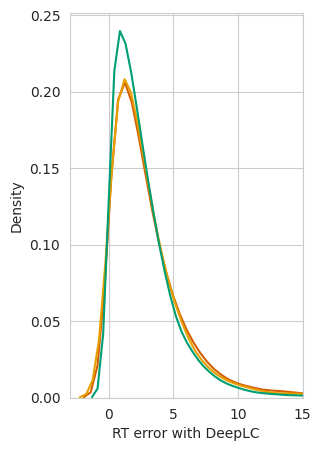

In [43]:
plt.figure(figsize=(3,5))
ax=sns.kdeplot(
    features_all,
    x='rt_diff',
    hue='match_type',
    palette=status_lut,
    common_norm=False,
    hue_order=hue_order,
    legend=False
)

plt.xlim(-3, 15)
plt.xlabel('RT error with DeepLC')

In [52]:
summary, density = kde_source_data(
    ax, features_all, value='rt_diff', group='match_type',
    group_order=hue_order, figure="Figure 8D")

with pd.ExcelWriter("source_data/Source_Data_Figure5.xlsx", engine="openpyxl", mode='a',if_sheet_exists='replace') as xl:
    summary.round(4).to_excel(xl, sheet_name="E_summary", index=False)
    density.round(6).to_excel(xl, sheet_name="E_density", index=False)